## EXPERIMENTALLY TESTING THE EFFECT OF THE NUMBER OF INHIBITORY SYNAPSES ON POSTSYNAPTIC NEURON DYNAMICS

### Initial set-up
In the code cells below:
- The terminal is called to create a new project folder, called stellate_to_purkinje
- Necessary modules are imported and current working directory is changed to the folder just created 
- The terminal is called to download the necessary cell morphologies and definitions 



In [1]:
!python -m bsb new stellate_to_purkinje --quickstart --json

Created 'stellate_to_purkinje' project structure.


In [1]:
import os 
os.chdir('stellate_to_purkinje')

In [2]:
%matplotlib inline

import bsb
from collections.abc import Mapping
import json
import matplotlib.pylab as plt
import numpy as np
import os
from sys import path

In [4]:
!curl -o StellateCell.swc https://raw.githubusercontent.com/dbbs-lab/models/refs/heads/main/dbbs_models/morphologies/StellateCell.swc
!curl -o Stellate.py https://raw.githubusercontent.com/dbbs-lab/models/refs/heads/main/dbbs_models/stellate_cell_models.py

!curl -o PurkinjeCell.swc https://raw.githubusercontent.com/dbbs-lab/models/refs/heads/main/dbbs_models/morphologies/PurkinjeCell.swc
!curl -o Purkinje.py https://raw.githubusercontent.com/dbbs-lab/models/refs/heads/main/dbbs_models/purkinje_cell_models.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  275k  100  275k    0     0   753k      0 --:--:-- --:--:-- --:--:--  761k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  5139  100  5139    0     0  21403      0 --:--:-- --:--:-- --:--:-- 21592
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  169k  100  169k    0     0   358k      0 --:--:-- --:--:-- --:--:--  360k
  % Total    % Received % Xferd  Average Speed   

### Morphologies plots
In the code cells below:
- A function to plot a 3D representation of a morphology file is defined 
- Morphologies of the Stellate Cell and of the Purkinje Cell are plotted 

In [5]:
def plot_morphology(morphology_file:str, title:str):
    morphology = bsb.parse_morphology_file(morphology_file)

    fig = plt.figure(figsize=(10, 10))
    ax1 = fig.add_subplot(111, projection='3d')
    for branch in morphology.branches:
        x, y, z = branch.points.T
        is_axon = np.array([np.isin(list(branch.labelsets[branch.labels[i]]), ["axon"]).any() for i in range(len(branch.points))])
        dendrite, = ax1.plot(x[~is_axon], y[~is_axon], z[~is_axon], color='blue')
        axon, = ax1.plot(x[is_axon], y[is_axon], z[is_axon], color='red')
    ax1.set_xlabel("x [µm]")
    ax1.set_ylabel("y [µm]")
    ax1.set_zlabel("z [µm]")
    ax1.legend([dendrite, axon], ["dendrites", "axon"])
    ax1.set_title(title)
    plt.show()

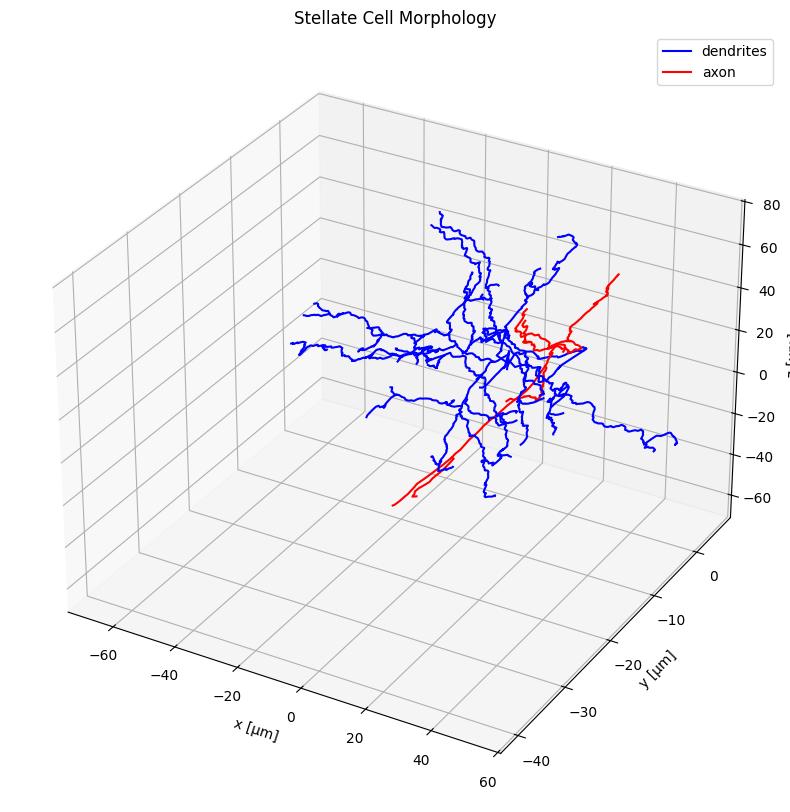

In [6]:
plot_morphology("StellateCell.swc", "Stellate Cell Morphology")

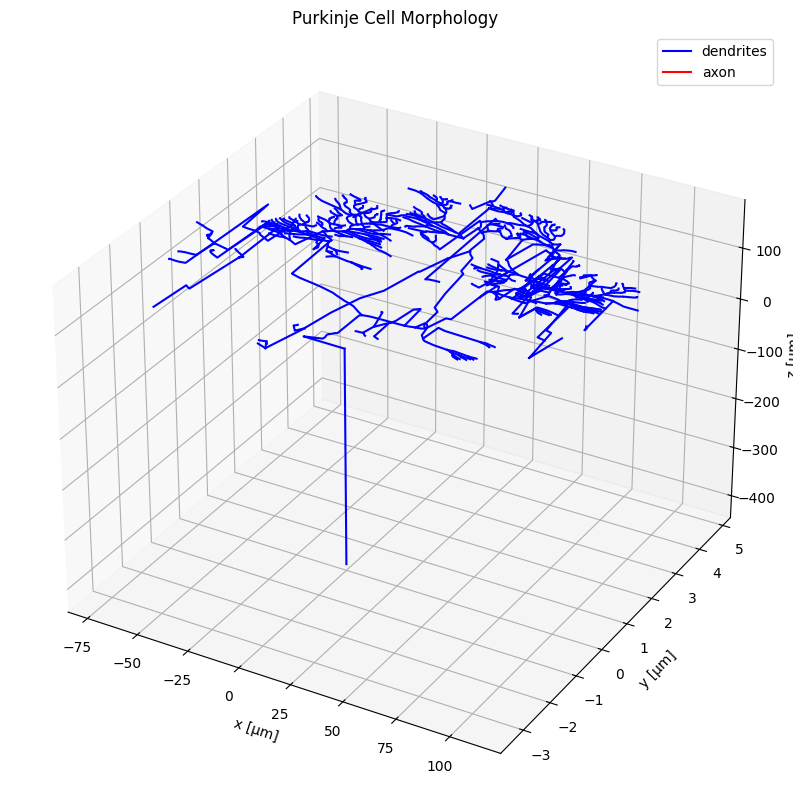

In [7]:
plot_morphology("PurkinjeCell.swc", "Purkinje Cell Morphology")

### Configurations set-up
In the code cell below:
- A function to build a BSB json configuration is defined
- The function has helped to build three networks, which contain the same parameters with the exception of the affinity, that is the parameter that differs for every simulation

In [ ]:
def get_net_config(level:str):
    if level == "low":
        name = "low_connectivity_network"
        affinity = 0.1
    elif level == "medium":
        name = "medium_connectivity_network"
        affinity = 0.5
    elif level == "high":
        name = "high_connectivity_network"
        affinity = 0.9
    else:
        raise ValueError("Invalid connectivity level. Must be 'low', 'medium', or 'high'.")
    return {
            "name" : name, # Name of the network, used for storage and logging
            "storage": {
                "engine": "hdf5", # Storage engine to use for storing the network and simulation results
                "root": f"{name}.hdf5" # Root file for storing the network and simulation results
            },
            "network": { # Network dimensions in microns
                "x": 200, # The dimensions of the network must allow the placement of the cells, based on the parameter "radius"
                "y": 200,
                "z": 200 # Total thickness of the layers
                },
            "partitions": { # Partitions of the network
                "stellate_layer": {
                    "type": "layer",
                    "thickness": 100
                },
                "purkinje_layer": {
                    "type": "layer",
                    "thickness": 100 # 100 + 100 = 200, which is the total thickness of the network
                }
            },
            "regions": { # Regions of the network
                "region": {
                    "type": "stack",
                    "children": ["stellate_layer", "purkinje_layer"]
                }
            },
            "cell_types": { # Cell types in the network
                "stellate_cell": {
                    "spatial": {
                        "radius": 2.5, 
                        "density": 0.00004, # Density of cells, in cells per cubic micron
                        "morphologies": ["StellateCell"]
                    }
                },
                "purkinje_cell": {
                    "spatial": {
                        "radius": 7,
                        "count": 40, # Number of cells to place in the network
                        "morphologies": ["PurkinjeCell"]
                    }
                }
            },
            "placement": { # Cell placement strategies
                "stellate_placement": {
                    "strategy": "bsb.placement.RandomPlacement", # The strategy to use for placing the cells, random placement
                    "partitions": ["stellate_layer"], # In which partition(s)?
                    "cell_types": ["stellate_cell"] # Which cell type(s) to place with this strategy?
                },
                "purkinje_placement": {
                    "strategy": "bsb.placement.RandomPlacement",
                    "partitions": ["purkinje_layer"],
                    "cell_types": ["purkinje_cell"]
                }
            },
            "connectivity": { # Connectivity strategies
                "stellate_to_purkinje": {
                    "strategy": "bsb.connectivity.VoxelIntersection", # VoxelIntersection creates a connection between two cells if their morphologies intersect in at least one voxel, and the probability of connection is given by the parameter "affinity"
                    "presynaptic": {   
                        "cell_types": ["stellate_cell"], # Which cell type(s) are presynaptic?
                        "morphology_labels": ["axon"] # Which morphology labels to consider for the presynaptic cell type(s)?
                    },
                    "postsynaptic": {
                        "cell_types": ["purkinje_cell"],
                        "morphology_labels": ["dendrites"] 
                    },
                    "affinity": affinity, # Probability of connection given a voxel intersection, between 0 and 1
                    "contacts": 1 # Number of synaptic contacts to create between two connected cells
                }
            },
            "morphologies": [
                {
                    "name": "PurkinjeCell",
                    "file": "PurkinjeCell.swc",
                    "parser": { # taken from the cell.py file
                        "tags": {
                            6: ["axon", "AIS"], 
                            7: ["axon", "AIS_K"], # by using "axon" as a label, "AIS", "AIS_K", "axonmyelin" and "nodes" will be considered as axon for connectivity and placement strategies
                            8: ["axon", "axonmyelin"],
                            9: ["axon", "nodes"],
                            10: ["dendrites", "basal_dendrites"],
                            11: ["dendrites", "pf_targets", "sc_targets"],
                            12: ["dendrites", "aa_targets", "sc_targets"],
                            13: ["dendrites", "sodium_dendrites"],
                        }
                    }
                },
                {
                    "name": "StellateCell",
                    "file": "StellateCell.swc",
                    "parser": {
                        "tags": {
                            6: ["dendrites", "proximal_dendrites"],
                            7: ["dendrites", "distal_dendrites"],
                            8: ["axon", "axon_initial_segment"],
                        }
                    }
                }
            ]
        }

### Networks constuction
In the code cells below:
- Three different network configurations are built 
- The first configuration has a low connectivity (affinity=0.1)
- The second configuration has a medium connectivity (affinity=0.5)
- The third configuration has a high connectivity (affinity=0.9)
- The json files containing the configurations are created 

In [9]:
low_connectivity_config = get_net_config("low")
medium_connectivity_config = get_net_config("medium")
high_connectivity_config = get_net_config("high")

In [10]:
with open("low_connectivity_config.json", "w") as f:
    json.dump(low_connectivity_config, f, indent=4)

with open("medium_connectivity_config.json", "w") as f:
    json.dump(medium_connectivity_config, f, indent=4)

with open("high_connectivity_config.json", "w") as f:
    json.dump(high_connectivity_config, f, indent=4)

In the code cell below:
- The terminal is called to build the networks in the respectives hdf5 files

In [11]:
!python -m bsb compile --verbosity 3 low_connectivity_config.json --clear
!python -m bsb compile --verbosity 3 medium_connectivity_config.json --clear
!python -m bsb compile --verbosity 3 high_connectivity_config.json --clear

Compiling the following strategies: stellate_placement, purkinje_placement, stellate_to_purkinje
[2026-02-28 02:30:15.334519 - BSB] JobStatus.RUNNING {root}.morphologies.PurkinjeCell
[2026-02-28 02:30:15.417767 - BSB] JobStatus.SUCCESS {root}.morphologies.PurkinjeCell
[2026-02-28 02:30:15.417767 - BSB] JobStatus.RUNNING {root}.morphologies.StellateCell
[2026-02-28 02:30:15.467998 - BSB] JobStatus.SUCCESS {root}.morphologies.StellateCell
Starting placement strategies: stellate_placement, purkinje_placement
[2026-02-28 02:30:15.484804 - BSB] JobStatus.RUNNING {root}.placement.purkinje_placement
Placing 10 purkinje_cell in [0 0 1]
[2026-02-28 02:30:15.518132 - BSB] JobStatus.SUCCESS {root}.placement.purkinje_placement
[2026-02-28 02:30:15.518132 - BSB] JobStatus.RUNNING {root}.placement.purkinje_placement
Placing 10 purkinje_cell in [0 1 1]
[2026-02-28 02:30:15.572480 - BSB] JobStatus.SUCCESS {root}.placement.purkinje_placement
[2026-02-28 02:30:15.572480 - BSB] JobStatus.RUNNING {root}.p

### Simulations set-up
In the code cell below:
- A function to update a json file is built

In [12]:
def update_json_configuration(
    update_dict: dict,
    configuration_filename: str="network_configuration.json",
    ):
    """
    Update the content of the BSB json configuration file with the dictionary
    given as input
    """
    if os.path.isfile(configuration_filename):
        with open(configuration_filename, "r") as f:
            data = json.load(f)
    else:
        data = {}

    deep_update(data, update_dict)

    with open(configuration_filename, "w") as f:
        json.dump(data, f, indent=4)

def deep_update(d: dict, u: Mapping):
    """
    Recursively update a dictionary d based on a dictionary u.
    u will overwrite any keys also in d.

    :return: merged dictionary
    :rtype: dict
    """
    for k, v in u.items():
        if isinstance(v, Mapping):
            d[k] = deep_update(d.get(k, {}), v)
        else:
            d[k] = v
    return d

In the code cell below:
- A function to build the simulation configuration is defined
- The low connectivity network will have a synapse weight equal to 0.01
- The mid connectivity network will have a synapse weight equal to 0.002
- The high connecectivity network will have a synapse weigth equal to 0.0011
- In all the three networks the aggregate synaptic input is in part preserved, maintaining constant the product affinity * weight = 0.001

In [ ]:
def get_sim_config(level:str):
    if level == "low":
        weight = 0.01 
    elif level == "medium":
        weight = 0.002
    elif level == "high":
        weight = 0.0011
    return {
            "simulations": {
                "connectivity_simulation": {
                    "simulator": "neuron",
                    "duration": 100.0, # Simulation duration in ms
                    "resolution": 0.025, # Simulation time step in ms
                    "temperature": 32.0,
                    "cell_models": {
                        "purkinje_cell": {
                            "model": "Purkinje.PurkinjeCellModel",
                            "parameters": []
                        },
                        "stellate_cell": {
                            "model": "Stellate.StellateCellModel",
                            "parameters": []
                        }
                    },
                    "connection_models": {
                        "stellate_to_purkinje": {
                            "synapses": [{
                                "synapse": "GABA",
                                "weight": weight,
                                "delay": 1.0
                            }]
                        }
                    },
                    "devices": {
                        "spike_burst": {
                            "device": "spike_generator",
                            "start": 10, # Starts at 10 ms
                            "number": 1, # Fires 1 spikes in total
                            "weight": 0.01,
                            "delay": 1,
                            "targetting": { 
                                "strategy": "sphere", # The strategy to use for targetting the device
                                "origin": [100, 100, 50], # The center of the sphere for the "sphere" strategy
                                "radius": 150, # The radius of the sphere for the "sphere" strategy 
                                "cell_models": ["stellate_cell"], # The cell models to target
                            },
                            "locations": { 
                                "strategy": "branch", 
                                "labels": ["dendrites"] 
                            },
                            "synapses" : ["AMPA"] 
                        },
                        "voltage_recorder": { 
                            "device": "voltage_recorder", 
                            "targetting": {
                                "strategy": "sphere", 
                                "origin": [100, 100, 150],
                                "radius": 150, # sqrt(200^2 + 200^2 + 100^2) = 300 is the diagonal of the layers, so a radius of 150 allows to target all the cells
                                "cell_models" : ["purkinje_cell"] # The cell models to target, a filter for the targettig strategy "sphere"
                            },
                            "locations": {
                                "strategy": "branch",
                                "labels": ["dendrites"]
                            }
                        },
                        "synapse_recorder": {
                            "device": "synapse_recorder", 
                            "synapse_types": ["GABA"], 
                            "targetting": { 
                                "strategy": "sphere", 
                                "origin": [100, 100, 150],
                                "radius": 150,
                                "cell_models" : ["purkinje_cell"]
                            },
                            "locations": {
                                "strategy": "branch",
                                "labels": ["dendrites"]
                            }
                        }
                    }
                }
            }
        }


In the code cells below:
- The three simulations configurations for the low, medium and high connectivity networks are built (first cell)
- The network configuration is updated using the function defined before (second cell)
- The terminal is used to reconfigure the three networks with the new simulations configurations (third cell)

In [14]:
low_sim_config = get_sim_config("low")
medium_sim_config = get_sim_config("medium")   
high_sim_config = get_sim_config("high")

In [15]:
low_connectivity_config = update_json_configuration(low_sim_config, configuration_filename="low_connectivity_config.json")
medium_connectivity_config = update_json_configuration(medium_sim_config, configuration_filename="medium_connectivity_config.json")
high_connectivity_config = update_json_configuration(high_sim_config, configuration_filename="high_connectivity_config.json")

In [16]:
!python -m bsb reconfigure low_connectivity_network.hdf5 low_connectivity_config.json
!python -m bsb reconfigure medium_connectivity_network.hdf5 medium_connectivity_config.json
!python -m bsb reconfigure high_connectivity_network.hdf5 high_connectivity_config.json

In the code cells below, general parameters of the networks are printed. In particular:
- The number of cells placed for each cell type
- The number of connections between the cells

In [17]:
scaffold_low = bsb.from_storage("low_connectivity_network.hdf5")
scaffold_medium = bsb.from_storage("medium_connectivity_network.hdf5")
scaffold_high = bsb.from_storage("high_connectivity_network.hdf5")

In [18]:
print("LOW CONNECTIVITY NETWORK")

for type_name, cell_type in scaffold_low.cell_types.items():
    ps = cell_type.get_placement_set()
    pos = ps.load_positions()
    print(f"{len(pos)} {type_name} placed")
    # The positions are a (Nx3) numpy array
    print("The median cell is located at", np.median(pos, axis=0))

stellate_to_purkinke = scaffold_low.get_connectivity_set("stellate_to_purkinje")

print("The number of stellate to purkinje connections is", len(stellate_to_purkinke.load_connections()))

LOW CONNECTIVITY NETWORK
160 stellate_cell placed
The median cell is located at [ 99.90726715 100.36019883  42.22708811]
40 purkinje_cell placed
The median cell is located at [ 97.15077942 105.52322308 146.52658136]
The number of stellate to purkinje connections is 28


In [19]:
print("MEDIUM CONNECTIVITY NETWORK")

for type_name, cell_type in scaffold_medium.cell_types.items():
    ps = cell_type.get_placement_set()
    pos = ps.load_positions()
    print(f"{len(pos)} {type_name} placed")
    # The positions are a (Nx3) numpy array
    print("The median cell is located at", np.median(pos, axis=0))

stellate_to_purkinke = scaffold_medium.get_connectivity_set("stellate_to_purkinje")

print("The number of stellate to purkinje connections is", len(stellate_to_purkinke.load_connections()))

MEDIUM CONNECTIVITY NETWORK
160 stellate_cell placed
The median cell is located at [ 98.98688278 100.43758561  52.78909945]
40 purkinje_cell placed
The median cell is located at [ 97.84252122  98.16730687 158.07882588]
The number of stellate to purkinje connections is 114


In [20]:
print("HIGH CONNECTIVITY NETWORK")

for type_name, cell_type in scaffold_high.cell_types.items():
    ps = cell_type.get_placement_set()
    pos = ps.load_positions()
    print(f"{len(pos)} {type_name} placed")
    # The positions are a (Nx3) numpy array
    print("The median cell is located at", np.median(pos, axis=0))

stellate_to_purkinke = scaffold_high.get_connectivity_set("stellate_to_purkinje")

print("The number of stellate to purkinje connections is", len(stellate_to_purkinke.load_connections()))

HIGH CONNECTIVITY NETWORK
160 stellate_cell placed
The median cell is located at [99.08837686 98.77493969 56.21864705]
40 purkinje_cell placed
The median cell is located at [ 99.87315698  94.30729277 161.11669087]
The number of stellate to purkinje connections is 276


In the code cells below:
- The terminal runs the simulations, storing the results in the respective folders

In [21]:
!python -m bsb simulate low_connectivity_network.hdf5 connectivity_simulation -o low_connectivity_results -v 3

Preparing simulation
Load balancing
Creating neurons
Creating transmitters
Allocated GIDs 0 to 28
Creating devices
Simulating...
Finished simulation.


In [22]:
!python -m bsb simulate medium_connectivity_network.hdf5 connectivity_simulation -o medium_connectivity_results -v 3

Preparing simulation
Load balancing
Creating neurons
Creating transmitters
Allocated GIDs 0 to 114
Creating devices
Simulating...
Finished simulation.


In [8]:
!python -m bsb simulate high_connectivity_network.hdf5 connectivity_simulation -o high_connectivity_results -v 3

Preparing simulation
Load balancing
Creating neurons
Creating transmitters
Allocated GIDs 0 to 276
Creating devices
Simulating...
Finished simulation.


### Results
In the code cells below:
- Functions to display the results are defined
- Results are displayed in two plots for each network simulation
- The first graph plots the results from the voltage recorder
- The second graph plots the result from the synapse recorder

In [3]:
from neo import io

# Read simulation data
def read_simulation_results(results_folder: str):
    for f in os.listdir(results_folder):
        if f.endswith(".nio"):
            my_file_name = f"{results_folder}/{f}"
            break
    sim = io.NixIO(my_file_name, mode="ro")
    block = sim.read_all_blocks()[0]  # there is one block of data since
                                    # we only ran one simulation
    segment = block.segments[0]  # there is onw segment of data since
                                # our recordings are in the same time frame
    signals = segment.analogsignals  # we take the recorded signal from
                                        # membrane potential and synaptic currents
    return signals

In [4]:
def plot_all_signals(results_folder):
    """
    Plot the voltage and synaptic current signals recorded from the cells in the network, for a given simulation results folder. 
    The function reads the recorded signals from the simulation results, and plots them using matplotlib.
    """
    analog_signals = read_simulation_results(results_folder)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    neuron_counter = 0
    synapse_counter = 0
    already_plotted_neurons = set()
    already_plotted_synapses = set()
    
    for signal in analog_signals:

        cell_id = signal.annotations["cell_id"] # The cell ID is used to plot only one dendrite for each purkinje cell, and only one synapse for each postsynaptic neuron

        device_name = signal.name
        
        times = signal.times.magnitude
        values = signal.magnitude

        if device_name == "voltage_recorder" and cell_id not in already_plotted_neurons:
            ax1.plot(times, values)
            neuron_counter += 1
            already_plotted_neurons.add(cell_id)
        elif device_name == "synapse_recorder" and cell_id not in already_plotted_synapses:
            ax2.plot(times, values)
            synapse_counter += 1
            already_plotted_synapses.add(cell_id)

    ax1.set_title(f"Membrane Potential (Purkinje Cells: {neuron_counter})")
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("Voltage (mV)")


    ax2.set_title(f"GABA Synaptic Current (Postsynaptic Purkinje Cells: {synapse_counter})")
    ax2.set_xlabel("Time (ms)")
    ax2.set_ylabel("Current (nA)")

    plt.tight_layout()
    plt.show()

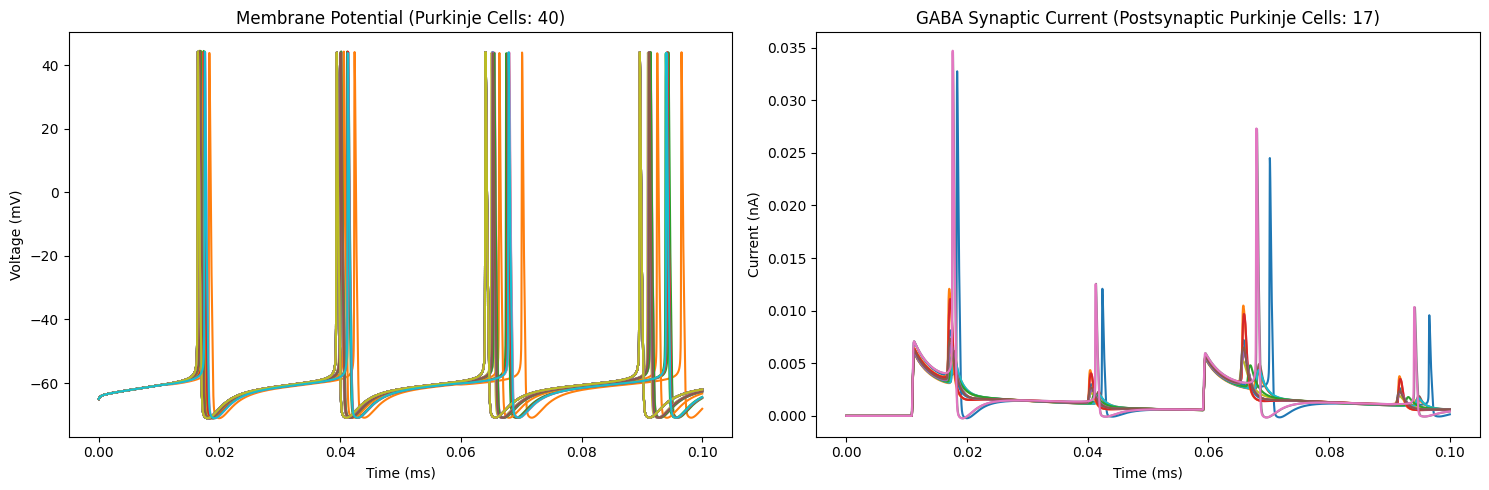

In [5]:
plot_all_signals("low_connectivity_results")

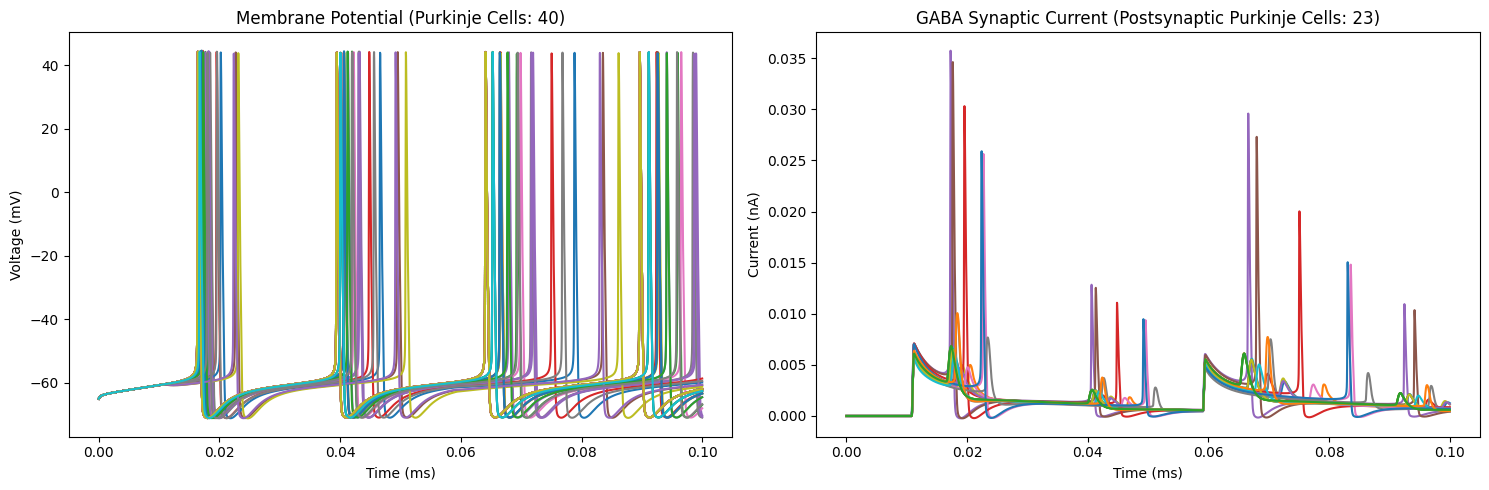

In [6]:
plot_all_signals("medium_connectivity_results")

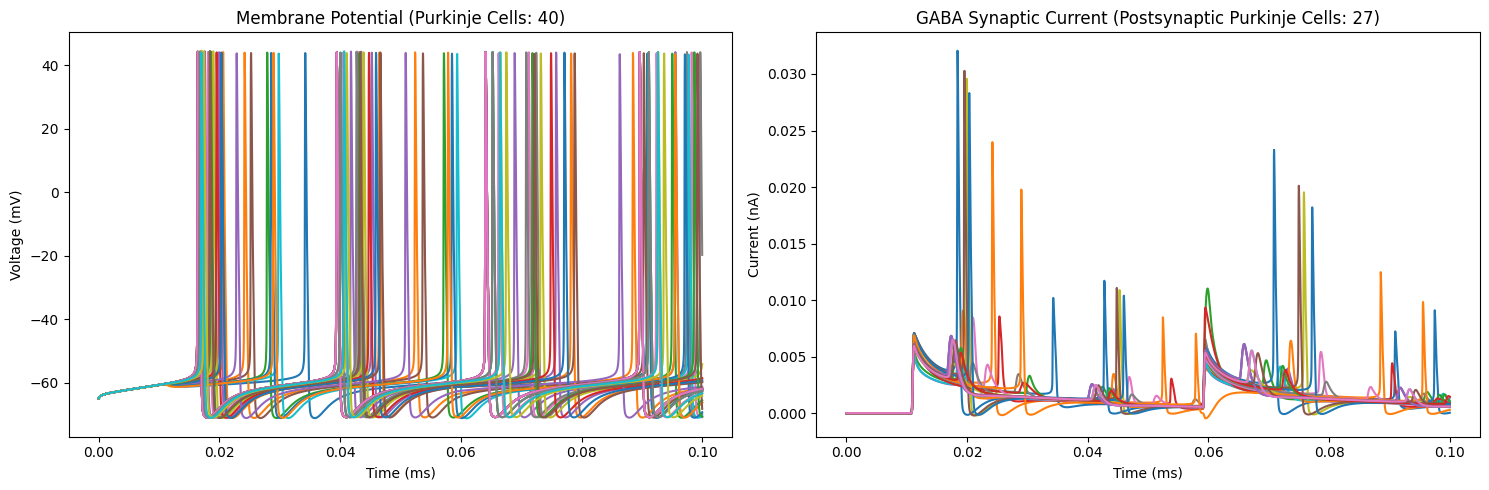

In [7]:
plot_all_signals("high_connectivity_results")